# 4.2 多話者音声コーパスのダウンロードと分析

# 4.2.1 JVSコーパスのダウンロード

In [ ]:
# --- JVSコーパスを gdown コマンドでダウンロード ---
# [注意!] このコードブロックは1回だけ実行すれば良いです。
!pip install gdown
!gdown https://drive.google.com/uc?id=19oAw8wWn3Y7z6CKChRdAyGOB9yupL_Xt

Downloading...
From (original): https://drive.google.com/uc?id=19oAw8wWn3Y7z6CKChRdAyGOB9yupL_Xt
From (redirected): https://drive.google.com/uc?id=19oAw8wWn3Y7z6CKChRdAyGOB9yupL_Xt&confirm=t&uuid=51981209-652f-4032-a77e-a0b0c2c27cff
To: /content/jvs_ver1.zip
100% 3.54G/3.54G [00:50<00:00, 69.5MB/s]


In [ ]:
# ダウンロードされた zip ファイルを解凍
# [注意!] このコードブロックは1回だけ実行すれば良いです。
!unzip jvs_ver1.zip

ストリーミング出力は最後の 5000 行に切り捨てられました。
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_084.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_042.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_089.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_025.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_083.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_074.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_050.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_065.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_030.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_018.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_035.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_085.lab  
  inflating: jvs_ver1/jvs044/parallel100/lab/mon/VOICEACTRESS100_023

# 4.2.2 librosa を用いたスペクトログラム分析

In [ ]:
# 必要なライブラリをインストール
!pip install librosa numpy matplotlib soundfile

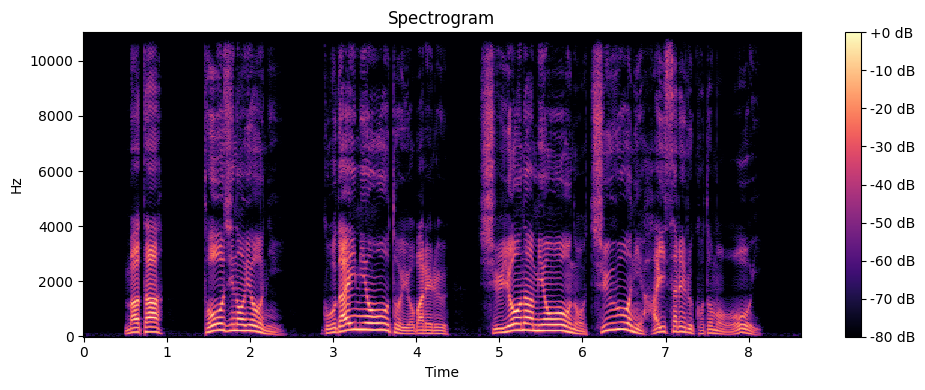

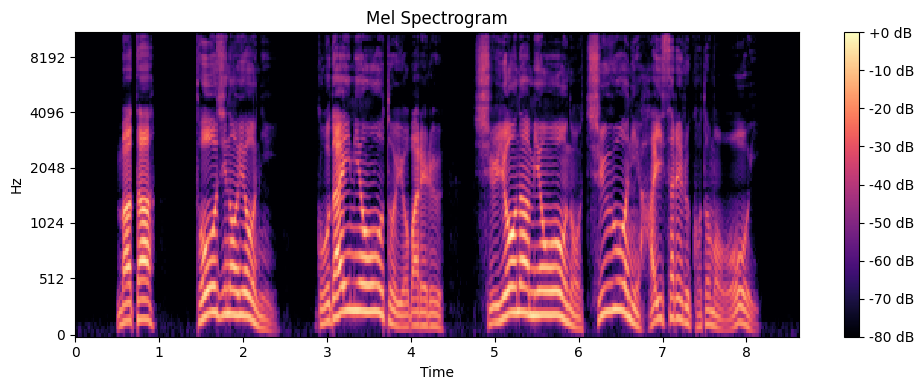

In [ ]:
# ライブラリをインポート
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

# 分析対象の音声ファイルをロード
audio_file = "jvs_ver1/jvs001/parallel100/wav24kHz16bit/VOICEACTRESS100_001.wav"
signal, sr = librosa.load(audio_file)

# Short-Time Fourier Transform (STFT) によりスペクトログラムを抽出
n_fft = 1024 # FFT のサンプル数
hop_length = 400 # STFT のシフト長
stft_result = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length) # STFT 分析
stft_magnitude = np.abs(stft_result) # 絶対値を取り、振幅スペクトルを計算
stft_db = librosa.amplitude_to_db(stft_magnitude, ref=np.max) # 振幅スペクトルを対数(dB)スケールに変換

# 対数振幅スペクトログラムを可視化
plt.figure(figsize=(10, 4))
librosa.display.specshow(stft_db, sr=sr, n_fft=n_fft, hop_length=hop_length, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB') # カラーバーを表示
plt.title('Spectrogram')
plt.tight_layout()
plt.show()

# メルスペクトログラムに変換するためのメルフィルタバンクを用意
n_mels = 100  # Number of Mel bands
mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels)

# 振幅スペクトログラムに対してメルフィルタバンクを適用
mel_spectrogram = np.dot(mel_basis, stft_magnitude)
mel_spectrogram_db = librosa.amplitude_to_db(mel_spectrogram, ref=np.max)

# メルスペクトログラムを可視化
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spectrogram_db, sr=sr, n_fft=n_fft, hop_length=hop_length, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.tight_layout()
plt.show()

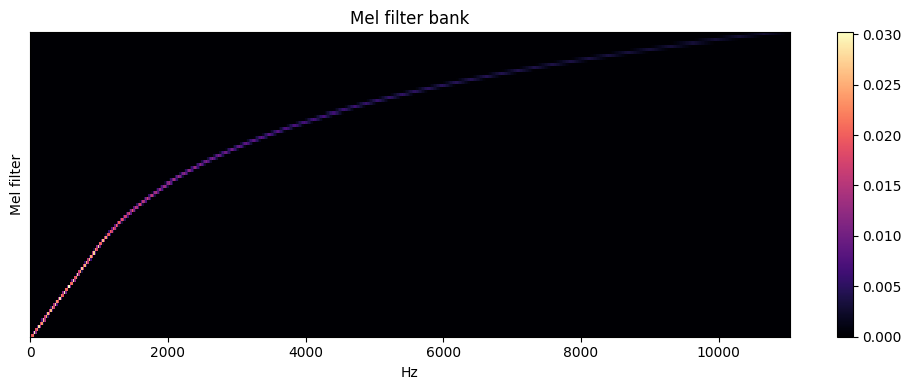

In [ ]:
# prompt: plot the mel_basis

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_basis, sr=sr, x_axis='linear')
plt.ylabel('Mel filter')
plt.title('Mel filter bank')
plt.colorbar()
plt.tight_layout()
plt.show()


# 4.2.3 深層学習のためのデータ前処理

In [ ]:
import os

# メルスペクトログラムを抽出する関数
def extract_mel_spectrograms(audio_dir, output_dir, n_fft=1024, n_mels=100, n_hop=400):
    """
    指定されたディレクトリにある wav ファイルからメルスペクトログラムを抽出

    Args:
        audio_dir:  抽出対象の wav ファイルがあるディレクトリ
        output_dir: 抽出されたメルスペクトログラムを保存するディレクトリ
        n_fft: FFT のサンプル数 (default: 1024)
        n_mels: メルフィルタバンクのフィルタ数 (default: 100)
        n_hop: STFT のシフト長 (default: 256)
    Returns:
        None
    """

    spk_name = audio_dir.split(os.path.sep)[1] # 話者の名前を取得
    print(f"Processing speaker: {spk_name}")
    # output_dir がなければ作る
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # audio_dir の中にあるファイルに対して反復
    for filename in os.listdir(audio_dir):
        if filename.endswith(('.wav')):  # wav で終わるファイルだけ処理
            print(f"処理中のファイル: {filename}")
            filepath = os.path.join(audio_dir, filename)
            signal, sr = librosa.load(filepath) # 音声ファイルをロード

            # STFT 振幅スペクトログラムを抽出
            stft_result = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length)
            stft_magnitude = np.abs(stft_result)

            # メルスペクトログラムに変換するためのメルフィルタバンクを用意
            n_mels = 100  # Number of Mel bands
            mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels)

            # 振幅スペクトログラムに対してメルフィルタバンクを適用
            mel_spectrogram = np.dot(mel_basis, stft_magnitude)
            mel_spectrogram_db = librosa.amplitude_to_db(mel_spectrogram, ref=np.max)

            # メルスペクトログラムを npy 形式で保存
            output_filename = spk_name + "_" + os.path.splitext(filename)[0] + ".npy"
            output_filepath = os.path.join(output_dir, output_filename)
            np.save(output_filepath, mel_spectrogram_db)
            print(f"抽出されたメルスペクトログラム: {output_filepath}")

In [ ]:
# spk_list で指定された話者のメルスペクトログラムを抽出
spk_list = ['jvs001', 'jvs002', 'jvs003', 'jvs004', 'jvs005']
for spk in spk_list:
    audio_directory = "jvs_ver1/%s/parallel100/wav24kHz16bit" % spk
    output_directory = "processed_data/mel_spec"
    extract_mel_spectrograms(audio_directory, output_directory)

Processing speaker: jvs001
処理中のファイル: VOICEACTRESS100_043.wav
抽出されたメルスペクトログラム: processed_data/mel_spec/jvs001_VOICEACTRESS100_043.npy
処理中のファイル: VOICEACTRESS100_021.wav
抽出されたメルスペクトログラム: processed_data/mel_spec/jvs001_VOICEACTRESS100_021.npy
処理中のファイル: VOICEACTRESS100_011.wav
抽出されたメルスペクトログラム: processed_data/mel_spec/jvs001_VOICEACTRESS100_011.npy
処理中のファイル: VOICEACTRESS100_079.wav
抽出されたメルスペクトログラム: processed_data/mel_spec/jvs001_VOICEACTRESS100_079.npy
処理中のファイル: VOICEACTRESS100_035.wav
抽出されたメルスペクトログラム: processed_data/mel_spec/jvs001_VOICEACTRESS100_035.npy
処理中のファイル: VOICEACTRESS100_024.wav
抽出されたメルスペクトログラム: processed_data/mel_spec/jvs001_VOICEACTRESS100_024.npy
処理中のファイル: VOICEACTRESS100_062.wav
抽出されたメルスペクトログラム: processed_data/mel_spec/jvs001_VOICEACTRESS100_062.npy
処理中のファイル: VOICEACTRESS100_091.wav
抽出されたメルスペクトログラム: processed_data/mel_spec/jvs001_VOICEACTRESS100_091.npy
処理中のファイル: VOICEACTRESS100_098.wav
抽出されたメルスペクトログラム: processed_data/mel_spec/jvs001_VOICEACTRESS100_098.npy
処理中のファイル: VOICEACTR

In [ ]:
# モノフォンラベルから音素を抽出する関数
def extract_phoneme_labels(label_dir, output_dir):
    """
    指定されたディレクトリにあるモノフォンラベルファイルから音素を抽出

    Args:
        label_dir:  抽出対象のモノフォンラベルファイルがあるディレクトリ
        output_dir: 抽出された音素ラベルを保存するディレクトリ
    Returns:
        None
    """

    spk_name = label_dir.split(os.path.sep)[1] # 話者の名前を取得
    print(f"Processing speaker: {spk_name}")
    # output_dir がなければ作る
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # audio_dir の中にあるファイルに対して反復
    for filename in os.listdir(label_dir):
        if filename.endswith(('.lab')):  # lab で終わるファイルだけ処理
            print(f"処理中のファイル: {filename}")
            filepath = os.path.join(label_dir, filename)

            # 音素ラベルのリストを作成
            phonemes = []
            with open(filepath, 'r') as f:
                for line in f:
                    start_sec, end_sec, phoneme = line.strip().split()
                    phonemes.append(phoneme)

            # 音素ラベルを txt 形式で保存
            output_filename = spk_name + "_" + os.path.splitext(filename)[0] + ".txt"
            output_filepath = os.path.join(output_dir, output_filename)
            np.save(output_filepath, mel_spectrogram_db)
            with open(output_filepath, 'w') as f:
                f.write("\n".join(phonemes))
            print(f"抽出された音素ラベル: {output_filepath}")

In [ ]:
# spk_list で指定された話者の音素ラベルを抽出
spk_list = ['jvs001', 'jvs002', 'jvs003', 'jvs004', 'jvs005']
for spk in spk_list:
    lab_directory = "jvs_ver1/%s/parallel100/lab/mon" % spk
    output_directory = "processed_data/phone_lab"
    extract_phoneme_labels(lab_directory, output_directory)

Processing speaker: jvs001
処理中のファイル: VOICEACTRESS100_085.lab
抽出された音素ラベル: processed_data/phone_lab/jvs001_VOICEACTRESS100_085.txt
処理中のファイル: VOICEACTRESS100_095.lab
抽出された音素ラベル: processed_data/phone_lab/jvs001_VOICEACTRESS100_095.txt
処理中のファイル: VOICEACTRESS100_031.lab
抽出された音素ラベル: processed_data/phone_lab/jvs001_VOICEACTRESS100_031.txt
処理中のファイル: VOICEACTRESS100_079.lab
抽出された音素ラベル: processed_data/phone_lab/jvs001_VOICEACTRESS100_079.txt
処理中のファイル: VOICEACTRESS100_042.lab
抽出された音素ラベル: processed_data/phone_lab/jvs001_VOICEACTRESS100_042.txt
処理中のファイル: VOICEACTRESS100_008.lab
抽出された音素ラベル: processed_data/phone_lab/jvs001_VOICEACTRESS100_008.txt
処理中のファイル: VOICEACTRESS100_064.lab
抽出された音素ラベル: processed_data/phone_lab/jvs001_VOICEACTRESS100_064.txt
処理中のファイル: VOICEACTRESS100_034.lab
抽出された音素ラベル: processed_data/phone_lab/jvs001_VOICEACTRESS100_034.txt
処理中のファイル: VOICEACTRESS100_071.lab
抽出された音素ラベル: processed_data/phone_lab/jvs001_VOICEACTRESS100_071.txt
処理中のファイル: VOICEACTRESS100_093.lab
抽出された音素ラベル: processed

In [ ]:
import os

# 音素ラベルが保存されたディレクトリ
phone_lab_dir = "processed_data/phone_lab"

# lab ファイルの中で出現するすべての音素を保存するリストを用意
all_phonemes = []

# ディレクトリ内の音素ラベルについて反復
for filename in os.listdir(phone_lab_dir):
    if filename.endswith(".txt"):  # txt で終わるファイルだけを取得
        filepath = os.path.join(phone_lab_dir, filename)
        with open(filepath, 'r') as f:
            for line in f:
                phoneme = line.strip()
                all_phonemes.append(phoneme)

# set() で重複する音素は除外し、sorted() でアルファベット順にソート
unique_phonemes = sorted(set(all_phonemes))

# 音素をIDに変換する辞書 (dictionary) を作成
phoneme_to_id = {phoneme: i for i, phoneme in enumerate(unique_phonemes)}
print("Phoneme to ID mapping:", phoneme_to_id)

Phoneme to ID mapping: {'I': 0, 'N': 1, 'U': 2, 'a': 3, 'b': 4, 'by': 5, 'ch': 6, 'cl': 7, 'd': 8, 'e': 9, 'f': 10, 'g': 11, 'gy': 12, 'h': 13, 'hy': 14, 'i': 15, 'j': 16, 'k': 17, 'ky': 18, 'm': 19, 'my': 20, 'n': 21, 'ny': 22, 'o': 23, 'p': 24, 'pau': 25, 'py': 26, 'r': 27, 'ry': 28, 's': 29, 'sh': 30, 'sil': 31, 't': 32, 'ts': 33, 'u': 34, 'v': 35, 'w': 36, 'y': 37, 'z': 38}


In [ ]:
# 話者名をIDに変換する辞書（5名しかいないのでハードコーディング）
spk_to_id = { 'jvs001': 0, 'jvs002': 1, 'jvs003': 2, 'jvs004': 3, 'jvs005': 4 }

In [ ]:
# processed_data の中にあるファイルを train/validation/test セットに分割
# 音素ラベルが保存されたディレクトリ
phone_lab_dir = "processed_data/phone_lab"

# ディレクトリ内の音素ラベルについて反復
all_data = []
for filename in os.listdir(phone_lab_dir):
    if filename.endswith(".txt"):  # txt で終わるファイルだけを取得
        filepath = os.path.join(phone_lab_dir, filename)
        basename = os.path.splitext(filename)[0]
        spk_name = basename.split("_")[0]
        spk_id = spk_to_id[spk_name]
        with open(filepath, 'r') as f:
            phoneme_seq = f.readlines()
        phoneme_id_seq = [str(phoneme_to_id[phoneme.strip()]) for phoneme in phoneme_seq]

        # [ファイル名]|[話者ID]|[音素ID系列] のフォーマットでラベルを整理
        data = "%s|%d|%s" % (basename, spk_id, ",".join(phoneme_id_seq))
        all_data.append(data)

all_data = sorted(all_data)

# 発話のIDに応じてデータを分割
# ・001 ~ 090: train, 091 ~ 095: validation, 096 ~ 100: test
train_data = []
val_data = []
test_data = []
for data in all_data:
    basename, spk_id, phoneme_id_seq = data.split("|")
    utt_id = int(basename.split("_")[2])
    if utt_id <= 90:
        train_data.append(data)
    elif utt_id > 90 and utt_id <= 95:
        val_data.append(data)
    else:
        test_data.append(data)

In [ ]:
# 辞書と各データセットをファイルに保存
import json

# 音素-to-ID の辞書を保存
with open('processed_data/phoneme_to_id.json', 'w') as f:
    json.dump(phoneme_to_id, f)

# 話者-to-ID の辞書を保存
with open('processed_data/spk_to_id.json', 'w') as f:
    json.dump(spk_to_id, f)

# train/val/test データセットを保存
with open('processed_data/train.txt', 'w') as f:
    f.write("\n".join(train_data))
with open('processed_data/val.txt', 'w') as f:
    f.write("\n".join(val_data))
with open('processed_data/test.txt', 'w') as f:
    f.write("\n".join(test_data))

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

# JVS を用いて深層学習するための PyTorch Dataset を定義
class JVSDataset(Dataset):
    """
    JVSDataset のコンストラクタ

    Args:
        metadata_path: メタデータファイルのパス
        mel_spec_dir: メルスペクトログラムが保存されているディレクトリ
        transform: データの前処理として適用する関数 (default: None)

    """
    def __init__(self, metadata_path, mel_spec_dir, transform=None):
        self.mel_spec_dir = mel_spec_dir
        self.transform = transform
        self.data = [] # データを格納するリスト

        with open(metadata_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                file_id, speaker_id, phoneme_str = line.split('|')
                phoneme_labels = list(map(int, phoneme_str.split(',')))

                mel_file_path = os.path.join(mel_spec_dir, f"{file_id}.npy")
                if not os.path.exists(mel_file_path):
                    continue  # メルスペクトログラムのファイルがなければスキップ

                speaker_name = file_id.split('_')[0]  # jvs001 など

                self.data.append({
                    'speaker_name': speaker_name,
                    'file_name': f"{file_id}.npy",
                    'speaker_id': int(speaker_id),
                    'phoneme_labels': phoneme_labels,
                    'mel_file_path': mel_file_path
                })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        entry = self.data[idx]
        mel_spec = np.load(entry['mel_file_path'])
        mel_spec = torch.tensor(mel_spec, dtype=torch.float32)

        if self.transform:
            mel_spec = self.transform(mel_spec)

        return {
            'speaker_name': entry['speaker_name'],
            'file_name': entry['file_name'],
            'speaker_id': entry['speaker_id'],
            'phoneme_labels': torch.tensor(entry['phoneme_labels'], dtype=torch.long),
            'mel_spec': mel_spec.T
        }

In [ ]:
train_dataset = JVSDataset(
    metadata_path='processed_data/train.txt',
    mel_spec_dir='processed_data/mel_spec'
)

val_dataset = JVSDataset(
    metadata_path='processed_data/val.txt',
    mel_spec_dir='processed_data/mel_spec'
)

test_dataset = JVSDataset(
    metadata_path='processed_data/test.txt',
    mel_spec_dir='processed_data/mel_spec'
)

sample = train_dataset[0]
print(sample['speaker_name'])     # 例: jvs001
print(sample['file_name'])        # 例: jvs001_VOICEACTRESS100_001.npy
print(sample['speaker_id'])       # jvs001 の話者ID (0)
print(sample['phoneme_labels'])   # jvs001_VOICEACTRESS100_001 の発話内容に関する音素ラベル系列
print(sample['mel_spec'].shape)   # mel_spec の次元 (フレーム数, メルスペクトログラム次元)
print(len(train_dataset))      # train_dataset の長さ (450)

jvs001
jvs001_VOICEACTRESS100_001.npy
0
tensor([31, 19,  3, 32,  3, 25, 32, 23, 23, 16, 15, 21, 23, 37, 23, 23, 21, 15,
        25, 11, 23,  8,  3, 15, 20, 23, 23, 23, 23, 32, 23, 37, 23,  4,  3, 27,
         9, 27, 34, 25, 30, 34, 37, 23, 23, 21,  3, 20, 23, 23, 23, 23, 21, 23,
         6, 34, 34, 23, 23, 21, 15, 13,  3, 15, 29,  3, 27,  9, 27, 34, 17, 23,
        32, 23, 19, 23, 23, 23, 15, 31])
torch.Size([476, 100])
450


In [ ]:
from torch.nn.utils.rnn import pad_sequence

def jvs_collate_fn(batch):
    """
    各サンプルをバッチにまとめる関数。可変長のメルスペクトログラムに対応。
    Args:
        batch: 各要素が dict のリスト
    Returns:
        collated_data: バッチ化されたデータ
    """
    file_names = [item['file_name'] for item in batch]
    speaker_names = [item['speaker_name'] for item in batch]
    speaker_ids = torch.tensor([item['speaker_id'] for item in batch], dtype=torch.long)

    # メルスペクトログラムは (T, D) なので pad_sequence のためにリストに
    mel_specs = [item['mel_spec'] for item in batch]
    mel_specs_padded = pad_sequence(mel_specs, batch_first=True)  # shape: (B, T_max, D)

    # ラベルも pad (optional: padding 値 -1 などにする)
    phoneme_labels = [item['phoneme_labels'] for item in batch]
    phoneme_labels_padded = pad_sequence(phoneme_labels, batch_first=True, padding_value=-1)

    collated_data = {
        'file_names': file_names,
        'speaker_names': speaker_names,
        'speaker_ids': speaker_ids,
        'mel_specs': mel_specs_padded,              # (B, T_max, D)
        'phoneme_labels': phoneme_labels_padded,    # (B, L_max)
    }
    return collated_data


In [ ]:
from torch.utils.data import DataLoader
num_workers = 2
batch_size = 8
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=jvs_collate_fn,
    num_workers=num_workers  # 環境に応じて調整
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=jvs_collate_fn,
    num_workers=num_workers  # 環境に応じて調整
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=jvs_collate_fn,
    num_workers=num_workers  # 環境に応じて調整
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1D CNN に基づく話者識別モデル
class SpeakerClassifierConv1D(nn.Module):
    def __init__(self, input_dim=100, num_speakers=5, hidden_dims=[128, 256, 256], dropout=0.3):
        """
        Args:
            input_dim (int): メルスペクトログラムの次元数（例：100）
            num_speakers (int): 話者クラス数
            hidden_dims (list of int): Conv1Dのチャンネルサイズ
            dropout (float): ドロップアウト率
        """
        super(SpeakerClassifierConv1D, self).__init__()

        conv_layers = []
        in_channels = input_dim
        for out_channels in hidden_dims:
            conv_layers.append(nn.Conv1d(in_channels, out_channels, kernel_size=5, stride=1, padding=2))
            conv_layers.append(nn.BatchNorm1d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.MaxPool1d(kernel_size=2))
            in_channels = out_channels

        self.conv = nn.Sequential(*conv_layers)

        self.global_pool = nn.AdaptiveAvgPool1d(1)  # 時系列方向を平均化 (B, C, 1)

        self.classifier = nn.Sequential(
            nn.Flatten(),                           # (B, C, 1) → (B, C)
            nn.Dropout(dropout),
            nn.Linear(in_channels, num_speakers)    # (B, C) → (B, num_speakers)
        )

    def forward(self, x):
        """
        Args:
            x: メルスペクトログラムの Tensor (B, T, D)
        Returns:
            logits: (B, num_speakers)
        """
        x = x.transpose(1, 2)  # (B, T, D) → (B, D, T)
        x = self.conv(x)       # (B, C, T')
        x = self.global_pool(x)  # (B, C, 1)
        logits = self.classifier(x)  # (B, num_speakers)
        return logits

model = SpeakerClassifierConv1D(input_dim=100, num_speakers=5)

In [ ]:
from tqdm import tqdm

# 話者識別DNNを学習するためのループ
def train_with_validation(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=10,
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Args:
        model: 話者識別DNNモデル
        train_loader: 学習データローダー
        val_loader: 検証データローダー
        criterion: 損失関数
        optimizer: 最適化アルゴリズム
        num_epochs: 学習エポック数
        device: デバイス
    Returns:
        results: 学習結果の辞書
    """

    model.to(device)
    best_val_loss = 1e10
    results = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f"\n=== Epoch {epoch+1}/{num_epochs} ===")

        # ------------------
        # 学習ループ
        # ------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch in tqdm(train_loader, desc="Training"):
            inputs = batch['mel_specs'].to(device)      # (B, T, D)
            labels = batch['speaker_ids'].to(device)    # (B,)

            optimizer.zero_grad()
            outputs = model(inputs)                     # (B, num_classes)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_avg_loss = train_loss / train_total
        train_acc = train_correct / train_total
        print(f"[Train] Loss: {train_avg_loss:.4f}, Accuracy: {train_acc:.4f}")

        # ------------------
        # 検証ループ
        # ------------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validation"):
                inputs = batch['mel_specs'].to(device)
                labels = batch['speaker_ids'].to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')

        val_avg_loss = val_loss / val_total
        val_acc = val_correct / val_total
        print(f"[Val]   Loss: {val_avg_loss:.4f}, Accuracy: {val_acc:.4f}")
        results['train_loss'].append(train_avg_loss)
        results['train_acc'].append(train_acc)
        results['val_loss'].append(val_avg_loss)
        results['val_acc'].append(val_acc)
    return results

In [ ]:
lr = 1e-3
num_epochs = 20

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

results = train_with_validation(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optimizer,
    num_epochs=num_epochs
)


=== Epoch 1/20 ===


Training: 100%|██████████| 57/57 [00:12<00:00,  4.45it/s]


[Train] Loss: 0.4067, Accuracy: 0.9200


Validation: 100%|██████████| 4/4 [00:00<00:00,  4.02it/s]


[Val]   Loss: 0.8487, Accuracy: 0.8000

=== Epoch 2/20 ===


...

[Val]   Loss: 0.0586, Accuracy: 1.0000

=== Epoch 20/20 ===


Training: 100%|██████████| 57/57 [00:12<00:00,  4.58it/s]


[Train] Loss: 0.0197, Accuracy: 0.9978


Validation: 100%|██████████| 4/4 [00:00<00:00,  7.29it/s]

[Val]   Loss: 0.6500, Accuracy: 0.8000


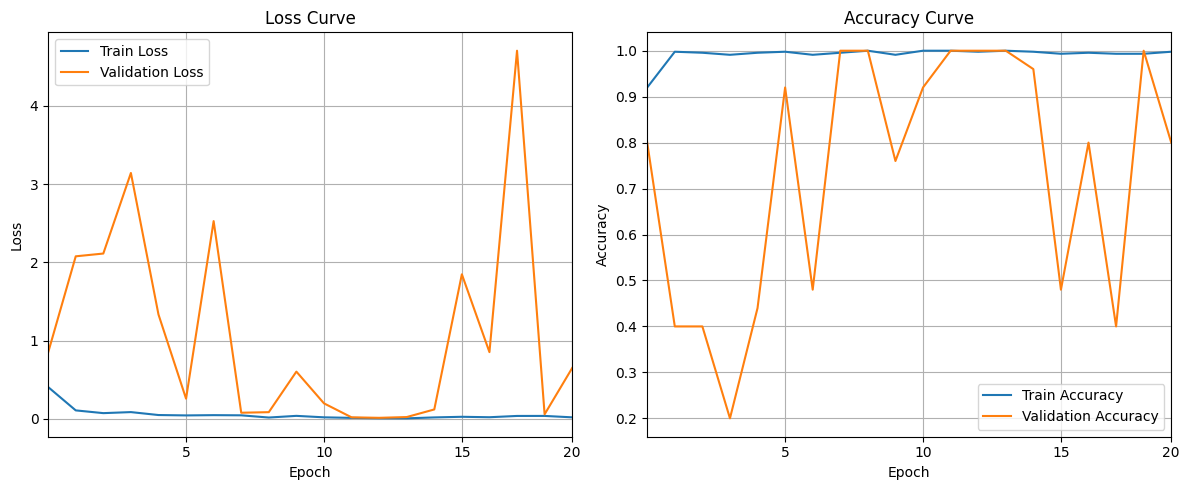

In [ ]:
import matplotlib.pyplot as plt
# 学習曲線のプロット
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss
axes[0].plot(results['train_loss'], label='Train Loss')
axes[0].plot(results['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlim(0, 19)
axes[0].set_xticks([5, 10, 15, 19])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(results['train_acc'], label='Train Accuracy')
axes[1].plot(results['val_acc'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlim(0, 19)
axes[1].set_xticks([5, 10, 15, 19])
axes[1].set_xticklabels([5, 10, 15, 20])
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import torch.nn.functional as F

def infer_speaker(model, test_loader, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    学習済みモデルを用いた話者識別

    Args:
        model: 学習済みモデル
        mel_spec_path: メルスペクトログラムを保存した npy ファイルのパス
        device: 推論に使用するデバイス
    Returns:
        speaker_id: 推論された話者ID
        probs: softmax スコア
    """
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    infer_results = {
        'test_loss': [],
        'test_acc': [],
        'test_pred': [],
        'test_gt': []
    }
    model.eval()
    model.to(device)
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Test"):
            inputs = batch['mel_specs'].to(device)
            labels = batch['speaker_ids'].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss = loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            test_correct += (preds == labels).sum().item()
            infer_results['test_pred'].append(preds.cpu().numpy()[0])
            infer_results['test_gt'].append(labels.cpu().numpy()[0])
            test_total += labels.size(0)
    test_avg_loss = test_loss / test_total
    test_acc = test_correct / test_total
    infer_results['test_loss'].append(test_avg_loss)
    infer_results['test_acc'].append(test_acc)
    return infer_results

In [ ]:
infer_results = infer_speaker(model, test_dataloader)

Test: 100%|██████████| 25/25 [00:00<00:00, 38.97it/s]

{'test_loss': [3.619030176196247e-06], 'test_acc': [1.0], 'test_pred': [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4)], 'test_gt': [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4)]}


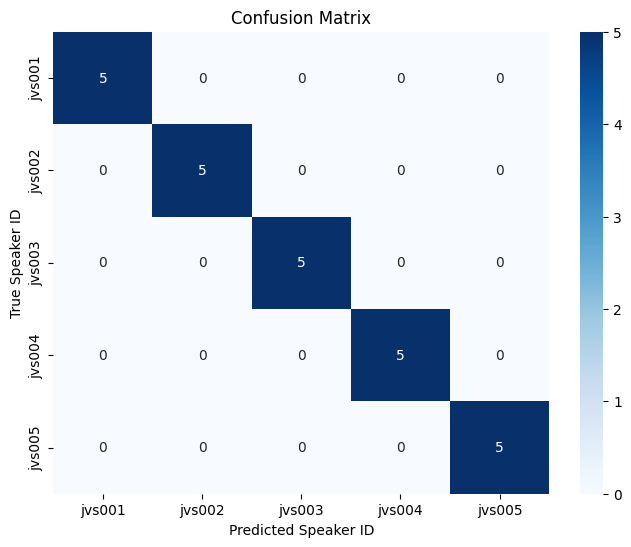

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import json

# 正解の話者ラベルと予測結果を辞書から獲得
y_true = infer_results['test_gt']
y_pred = infer_results['test_pred']

# 話者識別の混同行列を作成
cm = confusion_matrix(y_true, y_pred)

# spk_to_id の辞書から話者名を獲得
with open("processed_data/spk_to_id.json", "r") as f:
    spk_to_id = json.load(f)
spk_labels = list(spk_to_id.keys())

# 混同行列を図示
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=spk_labels, yticklabels=spk_labels)
plt.xlabel('Predicted Speaker ID')
plt.ylabel('True Speaker ID')
plt.title('Confusion Matrix')
plt.show()